# 05. Семантический baseline и supervised significance model

Этот ноутбук строит две модели для задачи **Semantic News Novelty**.

Первая часть — зафиксированный baseline:

1. принимает на вход данные в формате, аналогичном `lenta_clean_news.csv`;
2. при необходимости приводит файлы разметки/темплейты в простой схеме к clean-like формату;
3. строит sentence embeddings с помощью `BAAI/bge-m3`;
4. сам формирует `cluster_id`;
5. сам формирует `novelty_label` внутри кластеров через rule-based логику;
6. сохраняет prediction-файл в формате, совместимом с `04_evaluate_annotations_and_predictions.ipynb`.

Вторая часть — supervised-модель определения значимых обновлений:

1. использует зафиксированную baseline-кластеризацию;
2. обучается на silver-разметке;
3. переводит `novelty_label` в бинарный флаг `is_significant`;
4. считает признаки только по прошлым новостям кластера, чтобы избежать утечек из будущего;
5. добавляет признаки расстояния до previous-only центра кластера;
6. сохраняет predictions в той же simple eval-схеме.

Выход обеих моделей:

```text
news_id
published_at
topic
title
text
cluster_id
novelty_label
comment
needs_review
```

Важно: если на вход baseline подан файл разметки, baseline **не использует** входные `cluster_id`, `novelty_label`, `comment`, `needs_review`. Эти поля считаются выводом другой модели/аннотатора и игнорируются.


## 1. Импорты


In [118]:
from __future__ import annotations

import hashlib
import json
import math
import os
import pickle
import re
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    normalized_mutual_info_score,
    adjusted_rand_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
)

## 2. Конфигурация

`INPUT_PATH` может указывать как на clean-like файл, так и на файл в новой простой схеме разметки.

Clean-like формат аналогичен `lenta_clean_news.csv`:

```text
news_id, url, title, text, topic, tags, published_at,
text_length, text_num_words, title_length, title_num_words,
model_text, model_length, model_num_words
```

Новая простая схема разметки/темплейта:

```text
news_id, published_at, topic, title, text,
cluster_id, novelty_label, comment, needs_review
```

`FORCE_REDOWNLOAD_MODEL` нужен только если требуется заново скачать/сохранить sentence-transformer.

`FORCE_RECOMPUTE_EMBEDDINGS` нужен, если изменился входной датасет, колонка `model_text`, модель embeddings или способ подготовки текста.

Если меняются только пороги `STORY_THRESHOLD`, `MINOR_THRESHOLD`, `DUPLICATE_THRESHOLD` или временное окно, **переcохранять embedding-модель и пересчитывать embeddings не нужно**. Нужно только заново построить кластеры и predictions.


In [119]:
PROJECT_ROOT = Path.cwd().resolve().parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PREPARED_DIR = DATA_DIR / "prepared"
BASELINE_DIR = DATA_DIR / "baseline"

ARTIFACTS_DIR = DATA_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_ARTIFACTS_DIR = ARTIFACTS_DIR / "baseline"
BASELINE_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

# Основной вход.
# Рекомендуемый вариант для end-to-end baseline: полный candidate pool без выводов модели.
# Для быстрой проверки можно указать файл в простой схеме разметки; поля разметки будут проигнорированы.
INPUT_PATH = PREPARED_DIR / "lenta_golden_candidate_pool.csv"

# Опциональный reference для быстрой оценки прямо внутри этого ноутбука.
# Обычно здесь указывается human gold.
REFERENCE_PATH = PREPARED_DIR / "lenta_golden_set_human.csv"
RUN_INLINE_EVALUATION = True

OUTPUT_PATH = PREPARED_DIR / "lenta_baseline_predictions.csv"
SUMMARY_PATH = BASELINE_ARTIFACTS_DIR / "lenta_baseline_summary.json"

MODEL_NAME = "BAAI/bge-m3"
LOCAL_MODEL_DIR = BASELINE_ARTIFACTS_DIR / "sentence_transformer_bge_m3"
EMBEDDINGS_CACHE_DIR = BASELINE_ARTIFACTS_DIR / "embeddings_cache"
EMBEDDINGS_CACHE_DIR.mkdir(parents=True, exist_ok=True)

FORCE_REDOWNLOAD_MODEL = False
FORCE_RECOMPUTE_EMBEDDINGS = False
FORCE_RERUN_BASELINE = True

# Параметры кластеризации baseline.
STORY_THRESHOLD = 0.82
STORY_WINDOW_DAYS = 14
# Параметры rule-based novelty-разметки.
MINOR_THRESHOLD = 0.88
DUPLICATE_THRESHOLD = 0.90
REVIEW_MARGIN = 0.03

# Простое topic-wise ограничение: новости кластеризуются внутри одной рубрики.
USE_TOPIC_BLOCKING = True

# Диагностический grid search по параметрам кластеризации.
# Это не обучение модели, а способ понять чувствительность baseline к порогам, и выбрать оптимальные параметры для дальнейшей работы
RUN_CLUSTERING_GRID_SEARCH = False
GRID_STORY_THRESHOLDS = [0.76, 0.78, 0.80, 0.82, 0.84, 0.86]
GRID_STORY_WINDOW_DAYS = [3, 7, 14]

RUN_NOVELTY_GRID_SEARCH = False

GRID_MINOR_THRESHOLDS = [0.78, 0.80, 0.82, 0.84, 0.86, 0.88]
GRID_DUPLICATE_THRESHOLDS = [0.90, 0.92, 0.94, 0.96]

RANDOM_STATE = 42


## 3. Схемы и вспомогательные функции


In [120]:
CLEAN_LIKE_COLUMNS = [
    "news_id",
    "url",
    "title",
    "text",
    "topic",
    "tags",
    "published_at",
    "text_length",
    "text_num_words",
    "title_length",
    "title_num_words",
    "model_text",
    "model_length",
    "model_num_words",
]

SIMPLE_ANNOTATION_COLUMNS = [
    "news_id",
    "published_at",
    "topic",
    "title",
    "text",
    "cluster_id",
    "novelty_label",
    "comment",
    "needs_review",
]

PREDICTION_COLUMNS = SIMPLE_ANNOTATION_COLUMNS.copy()

VALID_NOVELTY_LABELS = ["significant", "minor", "duplicate", "wrong_cluster", "unclear"]
IMPORTANT_POSITIVE_LABEL = "significant"
IMPORTANT_NEGATIVE_LABELS = ["minor", "duplicate"]
IMPORTANT_EXCLUDED_LABELS = ["", "wrong_cluster", "unclear"]


def count_words(value: str) -> int:
    value = "" if pd.isna(value) else str(value)
    return len(re.findall(r"\w+", value, flags=re.UNICODE))


def normalize_news_id(series: pd.Series) -> pd.Series:
    return (
        series
        .astype(str)
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
    )


def normalize_bool_like(value) -> bool:
    if isinstance(value, bool):
        return value
    if pd.isna(value):
        return False
    value = str(value).strip().lower()
    return value in {"1", "true", "yes", "y", "да", "истина"}


def dataframe_content_hash(df: pd.DataFrame, columns: list[str]) -> str:
    h = hashlib.sha256()
    safe = df[columns].copy()
    for col in columns:
        safe[col] = safe[col].fillna("").astype(str)
    csv_bytes = safe.to_csv(index=False).encode("utf-8")
    h.update(csv_bytes)
    return h.hexdigest()[:16]


## 4. Подготовка входных данных

Baseline принимает clean-like формат, но для удобства может читать файлы в новой простой схеме разметки и приводить их к clean-like виду.

Новая простая схема должна содержать минимум:

```text
news_id, published_at, topic, title, text
```

Если в файле уже есть `cluster_id`, `novelty_label`, `comment`, `needs_review`, baseline их игнорирует. Эти поля будут заново сформированы на выходе.


In [121]:
def prepare_model_input(raw_df: pd.DataFrame) -> pd.DataFrame:
    """Привести входной файл к clean-like формату для baseline.

    Поддерживаются два типа входа:
    - clean-like датасет, аналогичный `lenta_clean_news.csv`;
    - файл в новой простой схеме разметки/темплейта:
      news_id, published_at, topic, title, text, cluster_id, novelty_label, comment, needs_review.

    Лишние колонки игнорируются.
    Недостающие технические колонки пересчитываются.
    """
    df = raw_df.copy()

    required_base = ["news_id", "published_at", "topic", "title", "text"]
    missing = [col for col in required_base if col not in df.columns]
    if missing:
        raise ValueError(f"Во входном файле отсутствуют обязательные колонки: {missing}")

    df["news_id"] = normalize_news_id(df["news_id"])
    df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")
    df["title"] = df["title"].fillna("").astype(str)
    df["text"] = df["text"].fillna("").astype(str)
    df["topic"] = df["topic"].fillna("unknown").astype(str)

    if df["published_at"].isna().any():
        bad_count = int(df["published_at"].isna().sum())
        raise ValueError(f"Найдено строк с некорректным published_at: {bad_count}")

    if "url" not in df.columns:
        df["url"] = ""
    if "tags" not in df.columns:
        df["tags"] = ""

    if "model_text" not in df.columns:
        df["model_text"] = (
            df["title"].fillna("")
            + "\n\n"
            + df["text"].fillna("")
        ).str.strip()
    else:
        df["model_text"] = df["model_text"].fillna("").astype(str)
        empty_model_text_mask = df["model_text"].str.strip().eq("")
        df.loc[empty_model_text_mask, "model_text"] = (
            df.loc[empty_model_text_mask, "title"].fillna("")
            + "\n\n"
            + df.loc[empty_model_text_mask, "text"].fillna("")
        ).str.strip()

    # Пересчитываем length-колонки, чтобы annotation-like вход тоже стал clean-like.
    df["text_length"] = df["text"].str.len()
    df["text_num_words"] = df["text"].map(count_words)
    df["title_length"] = df["title"].str.len()
    df["title_num_words"] = df["title"].map(count_words)
    df["model_length"] = df["model_text"].str.len()
    df["model_num_words"] = df["model_text"].map(count_words)

    df = df.sort_values(["published_at", "news_id"]).reset_index(drop=True)
    return df[CLEAN_LIKE_COLUMNS]


def prediction_output_from_model_input(df: pd.DataFrame) -> pd.DataFrame:
    out = df[["news_id", "published_at", "topic", "title", "text"]].copy()
    out["cluster_id"] = ""
    out["novelty_label"] = ""
    out["comment"] = ""
    out["needs_review"] = False
    return out[PREDICTION_COLUMNS]


## 5. Загрузка входного файла


In [122]:
raw_input = pd.read_csv(INPUT_PATH)
model_input = prepare_model_input(raw_input)

print("Входной файл:", INPUT_PATH)
print("Размер исходного файла:", raw_input.shape)
print("Размер clean-like входа модели:", model_input.shape)
print("Период:", model_input["published_at"].min(), "—", model_input["published_at"].max())
print("Распределение по темам:")
print(model_input["topic"].value_counts())

model_input.head(3)


Входной файл: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_golden_candidate_pool.csv
Размер исходного файла: (3176, 16)
Размер clean-like входа модели: (3176, 14)
Период: 2004-03-01 00:00:00 — 2004-04-30 00:00:00
Распределение по темам:
topic
Россия       1498
Мир          1370
Экономика     308
Name: count, dtype: int64


,news_id,url,title,text,topic,tags,published_at,text_length,text_num_words,title_length,title_num_words,model_text,model_length,model_num_words
0,88522,https://lenta.ru/news/2004/03/01/nato/,Расширение НАТО случится досрочно,Церемония принятия в НАТО новых членов состоит...,Мир,Все,2004-03-01,762,106,33,4,Расширение НАТО случится досрочно. Церемония п...,797,110
1,88525,https://lenta.ru/news/2004/03/01/kaloev/,Подозреваемый в убийстве диспетчера Skyguide г...,"Немецкие адвокаты, которые представляют интере...",Мир,Все,2004-03-01,2623,343,72,9,Подозреваемый в убийстве диспетчера Skyguide г...,2697,352
2,88528,https://lenta.ru/news/2004/03/01/constitution/,Правительственный совет Ирака одобрил проект в...,Члены Правительственного совета Ирака приняли ...,Мир,Все,2004-03-01,1371,168,66,7,Правительственный совет Ирака одобрил проект в...,1439,175


## 6. Реализация baseline

Baseline собран в переиспользуемый класс, чтобы ту же логику потом можно было перенести из ноутбука в сервис.

Класс не обучает supervised-модель. Метод `fit()` только готовит переиспользуемое состояние:

- загружает или скачивает pretrained SentenceTransformer;
- при необходимости сохраняет модель локально;
- считает или загружает из кеша embeddings для текущего входного набора.

Изменение порогов не требует заново сохранять SentenceTransformer и не требует пересчитывать embeddings. Нужно только заново выполнить кластеризацию и novelty-разметку.


In [123]:
@dataclass
class SemanticNewsBaselineConfig:
    model_name: str
    local_model_dir: Path
    embeddings_cache_dir: Path
    force_redownload_model: bool = False
    force_recompute_embeddings: bool = False
    story_threshold: float = 0.82
    story_window_days: int = 7
    minor_threshold: float = 0.78
    duplicate_threshold: float = 0.92
    review_margin: float = 0.03
    use_topic_blocking: bool = True
    batch_size: int = 32


class UnionFind:
    def __init__(self, n: int):
        self.parent = list(range(n))
        self.rank = [0] * n

    def find(self, x: int) -> int:
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x

    def union(self, a: int, b: int) -> None:
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            self.parent[ra] = rb
        elif self.rank[ra] > self.rank[rb]:
            self.parent[rb] = ra
        else:
            self.parent[rb] = ra
            self.rank[ra] += 1


class SemanticNewsBaseline:
    """Семантический baseline для кластеризации новостных сюжетов и novelty-разметки.

    Вход:
        clean-like dataframe с news_id, title, text, topic, published_at, model_text.

    Выход:
        prediction-like dataframe:
        news_id, published_at, topic, title, text, cluster_id, novelty_label, comment, needs_review.

    Класс намеренно устроен просто:
    - готовые sentence-transformer embeddings;
    - граф похожести внутри topic с временным окном;
    - компоненты связности как сюжетные кластеры;
    - rule-based novelty-метки по максимальной близости к предыдущим новостям кластера.
    """

    def __init__(self, config: SemanticNewsBaselineConfig):
        self.config = config
        self.model = None
        self.df_: Optional[pd.DataFrame] = None
        self.embeddings_: Optional[np.ndarray] = None
        self.last_graph_edges_: Optional[int] = None
        self.last_cluster_count_: Optional[int] = None

    def fit(self, df: pd.DataFrame) -> "SemanticNewsBaseline":
        self.df_ = prepare_model_input(df)
        self.model = self._load_sentence_transformer_model()
        self.embeddings_ = self._compute_or_load_embeddings(self.df_)
        return self

    def predict(
        self,
        story_threshold: Optional[float] = None,
        story_window_days: Optional[int] = None,
        minor_threshold: Optional[float] = None,
        duplicate_threshold: Optional[float] = None,
        review_margin: Optional[float] = None,
        use_topic_blocking: Optional[bool] = None,
    ) -> pd.DataFrame:
        if self.df_ is None or self.embeddings_ is None:
            raise RuntimeError("Сначала вызовите fit(df), затем predict().")

        story_threshold = self.config.story_threshold if story_threshold is None else story_threshold
        story_window_days = self.config.story_window_days if story_window_days is None else story_window_days
        minor_threshold = self.config.minor_threshold if minor_threshold is None else minor_threshold
        duplicate_threshold = self.config.duplicate_threshold if duplicate_threshold is None else duplicate_threshold
        review_margin = self.config.review_margin if review_margin is None else review_margin
        use_topic_blocking = self.config.use_topic_blocking if use_topic_blocking is None else use_topic_blocking

        working_df = self.df_.copy().reset_index(drop=True)
        cluster_ids = self._build_semantic_graph_clusters(
            working_df,
            self.embeddings_,
            story_threshold=story_threshold,
            story_window_days=story_window_days,
            use_topic_blocking=use_topic_blocking,
        )
        working_df["baseline_cluster_id"] = cluster_ids.values

        predictions = self._label_novelty_within_clusters(
            working_df,
            self.embeddings_,
            cluster_col="baseline_cluster_id",
            minor_threshold=minor_threshold,
            duplicate_threshold=duplicate_threshold,
            review_margin=review_margin,
        )
        return predictions

    def fit_predict(self, df: pd.DataFrame) -> pd.DataFrame:
        return self.fit(df).predict()

    def save_config(self, path: Path) -> None:
        payload = asdict(self.config)
        payload = {key: str(value) if isinstance(value, Path) else value for key, value in payload.items()}
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(payload, f, ensure_ascii=False, indent=2)

    def _load_sentence_transformer_model(self):
        from sentence_transformers import SentenceTransformer

        self.config.local_model_dir.mkdir(parents=True, exist_ok=True)

        if self.config.local_model_dir.exists() and any(self.config.local_model_dir.iterdir()) and not self.config.force_redownload_model:
            print(f"Загружаю локальную sentence-transformer модель из {self.config.local_model_dir}")
            return SentenceTransformer(str(self.config.local_model_dir))

        print(f"Загружаю sentence-transformer модель из Hugging Face: {self.config.model_name}")
        model = SentenceTransformer(self.config.model_name)
        model.save(str(self.config.local_model_dir))
        print(f"Локальная копия sentence-transformer сохранена в {self.config.local_model_dir}")
        return model

    def _get_embeddings_cache_path(self, df: pd.DataFrame) -> Path:
        input_hash = dataframe_content_hash(df, ["news_id", "published_at", "model_text"])
        model_hash = hashlib.sha256(self.config.model_name.encode("utf-8")).hexdigest()[:8]
        return self.config.embeddings_cache_dir / f"embeddings_{model_hash}_{input_hash}.npz"

    def _compute_or_load_embeddings(self, df: pd.DataFrame) -> np.ndarray:
        self.config.embeddings_cache_dir.mkdir(parents=True, exist_ok=True)
        cache_path = self._get_embeddings_cache_path(df)

        if cache_path.exists() and not self.config.force_recompute_embeddings:
            print(f"Загружаю embeddings из кеша: {cache_path}")
            data = np.load(cache_path, allow_pickle=False)
            embeddings = data["embeddings"]
            if embeddings.shape[0] != len(df):
                raise ValueError("Количество строк в кеше embeddings не совпадает с входным dataframe")
            return embeddings

        print("Считаю embeddings...")
        embeddings = self.model.encode(
            df["model_text"].tolist(),
            batch_size=self.config.batch_size,
            normalize_embeddings=True,
            show_progress_bar=True,
        )
        embeddings = np.asarray(embeddings, dtype=np.float32)
        np.savez_compressed(cache_path, embeddings=embeddings)
        print(f"Embeddings сохранены в кеш: {cache_path}")
        return embeddings

    def _build_semantic_graph_clusters(
        self,
        df: pd.DataFrame,
        embeddings: np.ndarray,
        story_threshold: float,
        story_window_days: int,
        use_topic_blocking: bool = True,
    ) -> pd.Series:
        n = len(df)
        uf = UnionFind(n)
        time_values = df["published_at"].to_numpy()

        if use_topic_blocking:
            groups = df.groupby("topic", sort=False).indices.values()
        else:
            groups = [np.arange(n)]

        max_delta = np.timedelta64(story_window_days, "D")
        total_edges = 0

        for raw_indices in groups:
            indices = np.array(list(raw_indices), dtype=int)
            if len(indices) <= 1:
                continue

            indices = indices[np.argsort(time_values[indices])]

            for local_i, global_i in enumerate(indices):
                j = local_i + 1
                while j < len(indices):
                    global_j = indices[j]
                    if time_values[global_j] - time_values[global_i] > max_delta:
                        break
                    sim = float(np.dot(embeddings[global_i], embeddings[global_j]))
                    if sim >= story_threshold:
                        uf.union(global_i, global_j)
                        total_edges += 1
                    j += 1

        roots = [uf.find(i) for i in range(n)]
        root_to_cluster = {}
        cluster_ids = []
        for root in roots:
            if root not in root_to_cluster:
                root_to_cluster[root] = f"baseline_cluster_{len(root_to_cluster):05d}"
            cluster_ids.append(root_to_cluster[root])

        self.last_graph_edges_ = total_edges
        self.last_cluster_count_ = len(set(cluster_ids))

        print("Рёбер в графе похожести:", total_edges)
        print("Количество кластеров:", self.last_cluster_count_)
        return pd.Series(cluster_ids, index=df.index)

    def _label_novelty_within_clusters(
        self,
        df: pd.DataFrame,
        embeddings: np.ndarray,
        cluster_col: str,
        minor_threshold: float,
        duplicate_threshold: float,
        review_margin: float,
    ) -> pd.DataFrame:
        result = prediction_output_from_model_input(df)
        result["cluster_id"] = df[cluster_col].values

        labels = [""] * len(df)
        comments = [""] * len(df)
        needs_review = [False] * len(df)

        for cluster_id, cluster_indices_raw in df.groupby(cluster_col, sort=False).indices.items():
            cluster_indices = list(cluster_indices_raw)
            cluster_indices = sorted(
                cluster_indices,
                key=lambda idx: (df.loc[idx, "published_at"], df.loc[idx, "news_id"]),
            )

            if not cluster_indices:
                continue

            first_idx = cluster_indices[0]
            comments[first_idx] = "старт_сюжета"
            labels[first_idx] = ""
            needs_review[first_idx] = False

            previous_indices = [first_idx]
            for idx in cluster_indices[1:]:
                sims = embeddings[previous_indices] @ embeddings[idx]
                best_pos = int(np.argmax(sims))
                max_sim = float(sims[best_pos])
                matched_idx = previous_indices[best_pos]
                matched_news_id = df.loc[matched_idx, "news_id"]

                if max_sim >= duplicate_threshold:
                    label = "duplicate"
                elif max_sim >= minor_threshold:
                    label = "minor"
                else:
                    label = "significant"

                near_threshold = (
                    abs(max_sim - duplicate_threshold) <= review_margin
                    or abs(max_sim - minor_threshold) <= review_margin
                )

                labels[idx] = label
                comments[idx] = (
                    f"max_prev_sim={max_sim:.3f}; "
                    f"matched_news_id={matched_news_id}; "
                    f"minor_threshold={minor_threshold:.2f}; "
                    f"duplicate_threshold={duplicate_threshold:.2f}"
                )
                needs_review[idx] = bool(near_threshold)
                previous_indices.append(idx)

        result["novelty_label"] = labels
        result["comment"] = comments
        result["needs_review"] = needs_review
        return result[PREDICTION_COLUMNS]


## 7. Запуск baseline


In [124]:
baseline_config = SemanticNewsBaselineConfig(
    model_name=MODEL_NAME,
    local_model_dir=LOCAL_MODEL_DIR,
    embeddings_cache_dir=EMBEDDINGS_CACHE_DIR,
    force_redownload_model=FORCE_REDOWNLOAD_MODEL,
    force_recompute_embeddings=FORCE_RECOMPUTE_EMBEDDINGS,
    story_threshold=STORY_THRESHOLD,
    story_window_days=STORY_WINDOW_DAYS,
    minor_threshold=MINOR_THRESHOLD,
    duplicate_threshold=DUPLICATE_THRESHOLD,
    review_margin=REVIEW_MARGIN,
    use_topic_blocking=USE_TOPIC_BLOCKING,
)

baseline = SemanticNewsBaseline(baseline_config)
baseline.fit(model_input)
baseline.save_config(BASELINE_ARTIFACTS_DIR / "semantic_baseline_config.json")

if OUTPUT_PATH.exists() and not FORCE_RERUN_BASELINE:
    print(f"Загружаю существующий файл predictions baseline: {OUTPUT_PATH}")
    baseline_predictions = pd.read_csv(OUTPUT_PATH)
else:
    baseline_predictions = baseline.predict()
    baseline_predictions.to_csv(OUTPUT_PATH, index=False)
    print("Predictions baseline сохранены:", OUTPUT_PATH)

print("Размер predictions:", baseline_predictions.shape)
print("Количество кластеров:", baseline_predictions["cluster_id"].nunique())
print("Распределение novelty_label:")
print(baseline_predictions["novelty_label"].replace("", "<старт_сюжета>").value_counts())
print("Доля needs_review:", baseline_predictions["needs_review"].map(normalize_bool_like).mean())

baseline_predictions.head(5)


Загружаю локальную sentence-transformer модель из E:\ML\Projects\Git\news-flow-analysis\data\artifacts\baseline\sentence_transformer_bge_m3


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Загружаю embeddings из кеша: E:\ML\Projects\Git\news-flow-analysis\data\artifacts\baseline\embeddings_cache\embeddings_d790e737_3cb8b68e5c8157fa.npz
Рёбер в графе похожести: 914
Количество кластеров: 2607
Predictions baseline сохранены: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_baseline_predictions.csv
Размер predictions: (3176, 9)
Количество кластеров: 2607
Распределение novelty_label:
novelty_label
<старт_сюжета>    2607
significant        427
minor               72
duplicate           70
Name: count, dtype: int64
Доля needs_review: 0.09319899244332494


,news_id,published_at,topic,title,text,cluster_id,novelty_label,comment,needs_review
0,88522,2004-03-01,Мир,Расширение НАТО случится досрочно,Церемония принятия в НАТО новых членов состоит...,baseline_cluster_00000,,старт_сюжета,False
1,88525,2004-03-01,Мир,Подозреваемый в убийстве диспетчера Skyguide г...,"Немецкие адвокаты, которые представляют интере...",baseline_cluster_00001,,старт_сюжета,False
2,88528,2004-03-01,Мир,Правительственный совет Ирака одобрил проект в...,Члены Правительственного совета Ирака приняли ...,baseline_cluster_00002,,старт_сюжета,False
3,88534,2004-03-01,Мир,Совет безопасности ООН одобрил отправку миротв...,Члены Совета безопасности ООН в воскресенье ве...,baseline_cluster_00003,,старт_сюжета,False
4,88536,2004-03-01,Россия,Дагестанская милиция нашла в горах погибших по...,В Цунтинском районе Дагестана обнаружены следы...,baseline_cluster_00004,,старт_сюжета,False


## 8. Вспомогательные функции для inline evaluation

Этот блок нужен, чтобы быстро оценить baseline на human gold прямо в `05`, не переключаясь в `04`.

Основной evaluation notebook всё равно остаётся `04`, но для подбора и диагностики baseline удобно видеть основные метрики здесь.

Метрики разделены на две группы:

1. **Основные** — те, которые напрямую отражают качество задачи и продуктовые риски.
2. **Второстепенные** — диагностические показатели, полезные для анализа, но не являющиеся главными критериями.


In [125]:
def load_prediction_like(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = SIMPLE_ANNOTATION_COLUMNS
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"В файле {path} отсутствуют колонки: {missing}")

    df = df[required].copy()
    df["news_id"] = normalize_news_id(df["news_id"])
    df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")
    df["cluster_id"] = df["cluster_id"].fillna("").astype(str).str.strip()
    df["novelty_label"] = df["novelty_label"].fillna("").astype(str).str.strip()
    df["needs_review"] = df["needs_review"].map(normalize_bool_like)
    return df


def compute_pairwise_clustering_metrics(reference_cluster_ids: Iterable[str], candidate_cluster_ids: Iterable[str]) -> dict:
    ref = np.array(list(reference_cluster_ids), dtype=object)
    cand = np.array(list(candidate_cluster_ids), dtype=object)
    n = len(ref)

    tp = fp = fn = tn = 0
    for i in range(n):
        for j in range(i + 1, n):
            ref_same = ref[i] == ref[j]
            cand_same = cand[i] == cand[j]
            if ref_same and cand_same:
                tp += 1
            elif not ref_same and cand_same:
                fp += 1
            elif ref_same and not cand_same:
                fn += 1
            else:
                tn += 1

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    false_merge_rate = fp / (tp + fp) if (tp + fp) else 0.0
    false_split_rate = fn / (tp + fn) if (tp + fn) else 0.0

    return {
        "n_items": n,
        "total_pairs": n * (n - 1) // 2,
        "tp_same_pairs": tp,
        "fp_false_merge_pairs": fp,
        "fn_false_split_pairs": fn,
        "tn_different_pairs": tn,
        "reference_same_pairs": tp + fn,
        "candidate_same_pairs": tp + fp,
        "pairwise_precision": precision,
        "pairwise_recall": recall,
        "pairwise_f1": f1,
        "false_merge_rate": false_merge_rate,
        "false_split_rate": false_split_rate,
        "adjusted_rand_index": adjusted_rand_score(ref, cand),
        "normalized_mutual_info": normalized_mutual_info_score(ref, cand),
    }


def to_important_binary(label: str):
    label = "" if pd.isna(label) else str(label).strip()
    if label == IMPORTANT_POSITIVE_LABEL:
        return 1
    if label in IMPORTANT_NEGATIVE_LABELS:
        return 0
    return np.nan


def evaluate_predictions(reference: pd.DataFrame, candidate: pd.DataFrame) -> tuple[pd.DataFrame, dict, pd.DataFrame]:
    merged = reference.merge(candidate, on="news_id", suffixes=("_ref", "_cand"), how="inner")

    coverage = len(merged) / len(reference) if len(reference) else 0.0

    clustering_metrics = compute_pairwise_clustering_metrics(
        merged["cluster_id_ref"],
        merged["cluster_id_cand"],
    )

    # Multiclass novelty metrics: только строки, где обе стороны выдали валидную непустую метку.
    ref_label = merged["novelty_label_ref"].fillna("").astype(str).str.strip()
    cand_label = merged["novelty_label_cand"].fillna("").astype(str).str.strip()
    valid_multiclass_mask = ref_label.isin(VALID_NOVELTY_LABELS) & cand_label.isin(VALID_NOVELTY_LABELS)

    novelty_metrics = {
        "novelty_eval_rows": int(valid_multiclass_mask.sum()),
        "novelty_accuracy": np.nan,
        "novelty_macro_f1": np.nan,
        "novelty_weighted_f1": np.nan,
        "cohen_kappa": np.nan,
    }

    if valid_multiclass_mask.any():
        y_ref = ref_label[valid_multiclass_mask]
        y_cand = cand_label[valid_multiclass_mask]
        novelty_metrics.update({
            "novelty_accuracy": accuracy_score(y_ref, y_cand),
            "novelty_macro_f1": f1_score(y_ref, y_cand, labels=VALID_NOVELTY_LABELS, average="macro", zero_division=0),
            "novelty_weighted_f1": f1_score(y_ref, y_cand, labels=VALID_NOVELTY_LABELS, average="weighted", zero_division=0),
            "cohen_kappa": cohen_kappa_score(y_ref, y_cand),
        })

    # Important-update metrics: significant против minor/duplicate.
    ref_binary = ref_label.map(to_important_binary)
    cand_binary = cand_label.map(to_important_binary)
    valid_binary_mask = ref_binary.notna() & cand_binary.notna()

    important_metrics = {
        "important_eval_rows": int(valid_binary_mask.sum()),
        "important_precision": np.nan,
        "important_recall": np.nan,
        "important_f1": np.nan,
    }

    if valid_binary_mask.any():
        y_ref_bin = ref_binary[valid_binary_mask].astype(int)
        y_cand_bin = cand_binary[valid_binary_mask].astype(int)
        important_metrics.update({
            "important_precision": precision_score(y_ref_bin, y_cand_bin, zero_division=0),
            "important_recall": recall_score(y_ref_bin, y_cand_bin, zero_division=0),
            "important_f1": f1_score(y_ref_bin, y_cand_bin, zero_division=0),
        })

    summary = {
        "reference_rows": len(reference),
        "candidate_rows": len(candidate),
        "overlap_rows": len(merged),
        "coverage": coverage,
        **clustering_metrics,
        **novelty_metrics,
        **important_metrics,
    }

    summary_df = pd.DataFrame.from_dict(summary, orient="index", columns=["value"])
    return merged, summary, summary_df


def metric_status(value, target, direction: str) -> str:
    if pd.isna(value) or target is None:
        return "INFO"
    if direction == ">=":
        return "OK" if value >= target else "WARN"
    if direction == "<=":
        return "OK" if value <= target else "WARN"
    return "INFO"


MAIN_METRIC_SPECS = [
    {
        "metric": "coverage",
        "name_ru": "Покрытие reference по news_id",
        "target": 0.95,
        "direction": ">=",
        "comment": "Sanity-check: сравниваются ли одни и те же новости.",
    },
    {
        "metric": "pairwise_f1",
        "name_ru": "Pairwise F1 кластеризации",
        "target": 0.75,
        "direction": ">=",
        "comment": "Основная метрика качества группировки инфоповодов.",
    },
    {
        "metric": "false_merge_rate",
        "name_ru": "Доля ложных склеек",
        "target": 0.15,
        "direction": "<=",
        "comment": "Критичный риск: разные сюжеты ошибочно объединяются.",
    },
    {
        "metric": "important_recall",
        "name_ru": "Recall важных обновлений",
        "target": 0.80,
        "direction": ">=",
        "comment": "Критичный риск: модель не должна пропускать significant updates.",
    },
    {
        "metric": "important_f1",
        "name_ru": "F1 важных обновлений",
        "target": 0.75,
        "direction": ">=",
        "comment": "Баланс precision/recall по классу significant.",
    },
]


SECONDARY_METRICS = [
    "pairwise_precision",
    "pairwise_recall",
    "false_split_rate",
    "adjusted_rand_index",
    "normalized_mutual_info",
    "novelty_eval_rows",
    "novelty_accuracy",
    "novelty_macro_f1",
    "novelty_weighted_f1",
    "cohen_kappa",
    "important_eval_rows",
    "important_precision",
    "n_items",
    "total_pairs",
    "tp_same_pairs",
    "fp_false_merge_pairs",
    "fn_false_split_pairs",
    "tn_different_pairs",
    "reference_same_pairs",
    "candidate_same_pairs",
]


def split_evaluation_summary(summary: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    main_rows = []
    for spec in MAIN_METRIC_SPECS:
        value = summary.get(spec["metric"], np.nan)
        main_rows.append({
            "metric": spec["metric"],
            "name_ru": spec["name_ru"],
            "value": value,
            "target": f'{spec["direction"]} {spec["target"]}',
            "status": metric_status(value, spec["target"], spec["direction"]),
            "comment": spec["comment"],
        })

    secondary_rows = []
    for metric in SECONDARY_METRICS:
        if metric in summary:
            secondary_rows.append({
                "metric": metric,
                "value": summary.get(metric),
            })

    return pd.DataFrame(main_rows), pd.DataFrame(secondary_rows)


## 9. Inline evaluation относительно reference

Если `REFERENCE_PATH` существует, baseline сразу сравнивается с reference-файлом. Обычно здесь указывается `lenta_golden_set_human.csv`.

Важно: если `coverage` низкий, метрики нельзя интерпретировать. Это значит, что baseline predictions и reference сделаны на разных поколениях файлов или разных наборах `news_id`.


In [126]:
if RUN_INLINE_EVALUATION and REFERENCE_PATH.exists():
    reference_df = load_prediction_like(REFERENCE_PATH)
    candidate_df = load_prediction_like(OUTPUT_PATH)
    merged_eval, eval_summary, eval_summary_df = evaluate_predictions(reference_df, candidate_df)
    main_metrics_df, secondary_metrics_df = split_evaluation_summary(eval_summary)

    print("Основные характеристики сравнения:")
    display(main_metrics_df)

    print("Второстепенные диагностические метрики:")
    display(secondary_metrics_df)

    if eval_summary["coverage"] < 0.95:
        print(
            "ВНИМАНИЕ: низкое покрытие reference по news_id. "
            "Скорее всего, reference и baseline predictions относятся к разным версиям данных."
        )

    reports_dir = ARTIFACTS_DIR / "inline_evaluation_reports"
    reports_dir.mkdir(parents=True, exist_ok=True)
    merged_eval.to_csv(reports_dir / "baseline_inline_merged_comparison.csv", index=False)
    eval_summary_df.to_csv(reports_dir / "baseline_inline_summary_all_metrics.csv")
    main_metrics_df.to_csv(reports_dir / "baseline_inline_summary_main_metrics.csv", index=False)
    secondary_metrics_df.to_csv(reports_dir / "baseline_inline_summary_secondary_metrics.csv", index=False)
    print("Отчёты inline evaluation сохранены в:", reports_dir)
else:
    print("Inline evaluation пропущен. Укажите RUN_INLINE_EVALUATION=True и существующий REFERENCE_PATH.")


Основные характеристики сравнения:


,metric,name_ru,value,target,status,comment
0,coverage,Покрытие reference по news_id,1.000000,>= 0.95,OK,Sanity-check: сравниваются ли одни и те же нов...
1,pairwise_f1,Pairwise F1 кластеризации,0.769737,>= 0.75,OK,Основная метрика качества группировки инфопово...
2,false_merge_rate,Доля ложных склеек,0.000000,<= 0.15,OK,Критичный риск: разные сюжеты ошибочно объедин...
3,important_recall,Recall важных обновлений,0.725490,>= 0.8,WARN,Критичный риск: модель не должна пропускать si...
4,important_f1,F1 важных обновлений,0.770833,>= 0.75,OK,Баланс precision/recall по классу significant.


Второстепенные диагностические метрики:


,metric,value
0,pairwise_precision,1.000000
1,pairwise_recall,0.625668
2,false_split_rate,0.374332
3,adjusted_rand_index,0.765079
4,normalized_mutual_info,0.941666
5,novelty_eval_rows,63.000000
6,novelty_accuracy,0.634921
7,novelty_macro_f1,0.232738
8,novelty_weighted_f1,0.659722
9,cohen_kappa,0.077070


Отчёты inline evaluation сохранены в: E:\ML\Projects\Git\news-flow-analysis\data\artifacts\inline_evaluation_reports


## 10. Диагностический grid search по параметрам кластеризации

Этот блок нужен, чтобы понять жёсткость проблемы и чувствительность baseline к порогам.

Важно: если использовать human gold для выбора параметров, это уже будет ручная калибровка. Для учебной baseline-версии можно показать grid как диагностику, но финальные параметры лучше зафиксировать заранее или явно описать как подобранные на dev-subset.


In [127]:
def run_grid_search_if_enabled():
    if not RUN_CLUSTERING_GRID_SEARCH:
        print("Grid search пропущен. Чтобы запустить, установите RUN_CLUSTERING_GRID_SEARCH=True.")
        return None
    if not REFERENCE_PATH.exists():
        print("Grid search пропущен: reference-файл не найден.")
        return None

    reference_df = load_prediction_like(REFERENCE_PATH)
    rows = []

    for story_window_days in GRID_STORY_WINDOW_DAYS:
        for story_threshold in GRID_STORY_THRESHOLDS:
            preds = baseline.predict(
                story_threshold=story_threshold,
                story_window_days=story_window_days,
                minor_threshold=MINOR_THRESHOLD,
                duplicate_threshold=DUPLICATE_THRESHOLD,
                review_margin=REVIEW_MARGIN,
                use_topic_blocking=USE_TOPIC_BLOCKING,
            )
            _, summary, _ = evaluate_predictions(reference_df, preds)
            rows.append({
                "story_threshold": story_threshold,
                "story_window_days": story_window_days,
                "minor_threshold": MINOR_THRESHOLD,
                "duplicate_threshold": DUPLICATE_THRESHOLD,
                "coverage": summary["coverage"],
                "pairwise_precision": summary["pairwise_precision"],
                "pairwise_recall": summary["pairwise_recall"],
                "pairwise_f1": summary["pairwise_f1"],
                "false_merge_rate": summary["false_merge_rate"],
                "false_split_rate": summary["false_split_rate"],
                "important_precision": summary["important_precision"],
                "important_recall": summary["important_recall"],
                "important_f1": summary["important_f1"],
                "novelty_macro_f1": summary["novelty_macro_f1"],
            })

    grid_df = pd.DataFrame(rows)
    grid_path = ARTIFACTS_DIR / "baseline_grid_search_results.csv"
    grid_df.to_csv(grid_path, index=False)
    print("Результаты grid search сохранены:", grid_path)
    return grid_df.sort_values(["false_merge_rate", "pairwise_f1"], ascending=[True, False])


grid_results = run_grid_search_if_enabled()
if grid_results is not None:
    display(grid_results.head(20))


Grid search пропущен. Чтобы запустить, установите RUN_CLUSTERING_GRID_SEARCH=True.


In [128]:
novelty_grid_rows = []

if RUN_NOVELTY_GRID_SEARCH:
    for minor_threshold in GRID_MINOR_THRESHOLDS:
        for duplicate_threshold in GRID_DUPLICATE_THRESHOLDS:
            if duplicate_threshold <= minor_threshold:
                continue

            config = SemanticNewsBaselineConfig(
                model_name=MODEL_NAME,
                local_model_dir=LOCAL_MODEL_DIR,
                embeddings_cache_dir=EMBEDDINGS_CACHE_DIR,
                story_threshold=STORY_THRESHOLD,
                story_window_days=STORY_WINDOW_DAYS,
                minor_threshold=minor_threshold,
                duplicate_threshold=duplicate_threshold,
                review_margin=REVIEW_MARGIN,
                force_redownload_model=False,
                force_recompute_embeddings=False,
            )
           

            baseline = SemanticNewsBaseline(config)
            predictions = baseline.fit_predict(model_input)

            _, summary, _ = evaluate_predictions(
                reference=reference_df,
                candidate=predictions,
            )

            row = {
                "minor_threshold": minor_threshold,
                "duplicate_threshold": duplicate_threshold,
                **summary,
            }

            novelty_grid_rows.append(row)

    novelty_grid_results = pd.DataFrame(novelty_grid_rows)

    novelty_grid_results.to_csv(
        ARTIFACTS_DIR / "baseline_novelty_grid_search_results.csv",
        index=False,
    )

    display(
        novelty_grid_results.sort_values(
            ["important_f1", "important_recall", "important_precision"],
            ascending=[False, False, False],
        ).head(20)
    )

## 11. Сохранение baseline summary


In [129]:
summary = {
    "input_path": str(INPUT_PATH),
    "output_path": str(OUTPUT_PATH),
    "model_name": MODEL_NAME,
    "local_model_dir": str(LOCAL_MODEL_DIR),
    "baseline_config_path": str(BASELINE_ARTIFACTS_DIR / "semantic_baseline_config.json"),
    "n_rows": int(len(model_input)),
    "period_min": str(model_input["published_at"].min()),
    "period_max": str(model_input["published_at"].max()),
    "story_threshold": STORY_THRESHOLD,
    "story_window_days": STORY_WINDOW_DAYS,
    "minor_threshold": MINOR_THRESHOLD,
    "duplicate_threshold": DUPLICATE_THRESHOLD,
    "review_margin": REVIEW_MARGIN,
    "use_topic_blocking": USE_TOPIC_BLOCKING,
    "graph_edges": int(baseline.last_graph_edges_) if baseline.last_graph_edges_ is not None else None,
    "n_clusters": int(baseline_predictions["cluster_id"].nunique()),
    "label_distribution": baseline_predictions["novelty_label"].replace("", "<старт_сюжета>").value_counts().to_dict(),
}

if RUN_INLINE_EVALUATION and REFERENCE_PATH.exists():
    summary["inline_evaluation_reference_path"] = str(REFERENCE_PATH)
    summary["inline_evaluation_all_metrics"] = eval_summary
    summary["inline_evaluation_main_metrics"] = main_metrics_df.to_dict(orient="records")
    summary["inline_evaluation_secondary_metrics"] = secondary_metrics_df.to_dict(orient="records")

with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Baseline summary сохранён:", SUMMARY_PATH)


Baseline summary сохранён: E:\ML\Projects\Git\news-flow-analysis\data\artifacts\baseline\lenta_baseline_summary.json


## 12. Заметки по бейзлайну

В этом ноутбуке baseline вынесен в переиспользуемый класс `SemanticNewsBaseline`.

Практические моменты:

- Изменение `STORY_THRESHOLD`, `STORY_WINDOW_DAYS`, `MINOR_THRESHOLD`, `DUPLICATE_THRESHOLD` или `REVIEW_MARGIN` не требует заново скачивать или сохранять SentenceTransformer.
- Эти изменения также не требуют пересчитывать embeddings, потому что embeddings зависят от входных текстов и embedding-модели, а не от порогов кластеризации.
- Чтобы принудительно пересчитать embeddings, установите `FORCE_RECOMPUTE_EMBEDDINGS = True`.
- Чтобы принудительно заново скачать/сохранить модель, установите `FORCE_REDOWNLOAD_MODEL = True`.
- Чтобы пересобрать prediction CSV после изменения параметров, установите `FORCE_RERUN_BASELINE = True`.

Финальная конфигурация baseline выбрана по результатам небольшого grid search. 
Для кластеризации выбран консервативный режим: высокий порог семантической близости и временное окно 14 дней. 
Это позволило сохранить низкий уровень ложных склеек сюжетов.

Для novelty-разметки порог `MINOR_THRESHOLD` был повышен до 0.88, так как исходная конфигурация слишком редко помечала новости как `significant` и давала низкий recall важных обновлений.

Baseline достигает приемлемого качества кластеризации (`pairwise_f1 ≈ 0.77` при целевых 0.75-0.8) при отсутствии ложных склеек (`false_merge_rate = 0.0`). 
Для важных обновлений baseline также показывает рабочий уровень (`important_f1 ≈ 0.77` при целевом 0.75), но recall всё ещё ниже целевого (`important_recall ≈ 0.73` при целевом 0.8).

Это делает baseline полезной точкой отсчёта: он уже не является совсем бесполезной моделью, но оставляет пространство для улучшения в основной модели.

## 13. Supervised-модель значимости обновления

Baseline выше остаётся зафиксированной точкой отсчёта: `BAAI/bge-m3`, graph clustering, rule-based novelty и параметры `0.82 / 14 / 0.88 / 0.90 / 0.03`.

Дальше строится отдельная рабочая модель. Она не меняет кластеризацию, а решает более устойчивую бинарную задачу:

```text
is_significant = 1, если novelty_label == "significant"
is_significant = 0, если novelty_label in {"minor", "duplicate"}
```

Это ближе к продуктовой задаче: найти новости, которые действительно добавляют важную новую информацию в сюжет.

Чтобы не было утечек из будущего, все признаки для новости считаются только по тем новостям того же кластера, которые опубликованы раньше неё.


In [130]:
# Imports для supervised-блока.
import joblib
from tqdm.auto import tqdm
from sklearn.model_selection import GroupShuffleSplit
from catboost import CatBoostClassifier


In [ ]:
# Пути supervised-модели.
SILVER_PATH = PREPARED_DIR / "lenta_silver_set_llm.csv"
HUMAN_GOLDEN_PATH = REFERENCE_PATH
BASELINE_PRED_PATH = OUTPUT_PATH

SIGNIFICANCE_ARTIFACTS_DIR = ARTIFACTS_DIR / "significance_model"
SIGNIFICANCE_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

SIGNIFICANCE_MODEL_PATH = SIGNIFICANCE_ARTIFACTS_DIR / "catboost_is_significant.joblib"
SIGNIFICANCE_CONFIG_PATH = SIGNIFICANCE_ARTIFACTS_DIR / "semantic_significance_model_config.json"
SIGNIFICANCE_FEATURES_PATH = SIGNIFICANCE_ARTIFACTS_DIR / "silver_significance_features.csv"
SIGNIFICANCE_VALIDATION_REPORT_PATH = SIGNIFICANCE_ARTIFACTS_DIR / "significance_validation_report.csv"
SIGNIFICANCE_COMPARISON_PATH = SIGNIFICANCE_ARTIFACTS_DIR / "baseline_vs_significance_model_inline_comparison.csv"

# Prediction-файл лежит рядом с baseline predictions, потому что его будет удобно сравнивать в notebook 04.
MODEL_OUTPUT_PATH = PREPARED_DIR / "lenta_model_predictions.csv"

# Отдельный id-based cache нужен supervised-модели.
# Baseline npz-cache привязан к конкретному dataframe, а здесь нужен общий доступ по news_id.
ID_EMBEDDINGS_CACHE_PATH = SIGNIFICANCE_ARTIFACTS_DIR / "bge_m3_embeddings_by_id.pkl"

# Параметры supervised-модели.
SIGNIFICANCE_THRESHOLD = 0.50
SIGNIFICANCE_REVIEW_MARGIN = 0.10
SIGNIFICANCE_VALIDATION_SIZE = 0.20


### 13.1. Embedding provider

Baseline уже умеет считать embeddings для своего входного dataframe. Но supervised-модель не должна зависеть от объекта `baseline`.

Поэтому ниже вынесен отдельный provider:

- загружает ту же локальную копию `BAAI/bge-m3`;
- хранит id-based cache `news_id -> embedding`;
- досчитывает только недостающие embeddings;
- может использоваться baseline, supervised-моделью и будущим сервисом независимо.


In [159]:
def make_embedding_source_df(df: pd.DataFrame) -> pd.DataFrame:
    """Подготовить dataframe с news_id и model_text для id-based embedding cache."""
    prepared = prepare_model_input(df)
    return prepared[["news_id", "model_text"]].copy()


class TextEmbeddingProvider:
    """Небольшой переиспользуемый слой для BAAI/bge-m3 embeddings.

    Provider специально отделён от baseline, чтобы supervised-модель не зависела
    от внутреннего состояния `SemanticNewsBaseline`.
    """

    def __init__(
        self,
        model_name: str,
        local_model_dir: Path,
        embeddings_cache_path: Path,
        batch_size: int = 32,
        force_redownload_model: bool = False,
    ):
        self.model_name = model_name
        self.local_model_dir = Path(local_model_dir)
        self.embeddings_cache_path = Path(embeddings_cache_path)
        self.batch_size = batch_size
        self.force_redownload_model = force_redownload_model
        self.model = None
        self.embeddings_by_id: dict[str, np.ndarray] = {}

    def load_model(self) -> "TextEmbeddingProvider":
        from sentence_transformers import SentenceTransformer

        self.local_model_dir.mkdir(parents=True, exist_ok=True)

        if (
            self.local_model_dir.exists()
            and any(self.local_model_dir.iterdir())
            and not self.force_redownload_model
        ):
            print(f"Загружаю sentence-transformer из локальной папки: {self.local_model_dir}")
            self.model = SentenceTransformer(str(self.local_model_dir))
        else:
            print(f"Загружаю sentence-transformer из Hugging Face: {self.model_name}")
            self.model = SentenceTransformer(self.model_name)
            self.model.save(str(self.local_model_dir))
            print(f"Локальная копия сохранена: {self.local_model_dir}")

        return self

    def load_cache(self) -> "TextEmbeddingProvider":
        if self.embeddings_cache_path.exists():
            with open(self.embeddings_cache_path, "rb") as f:
                self.embeddings_by_id = pickle.load(f)
            print(f"Загружен id-based embeddings cache: {len(self.embeddings_by_id)}")
        else:
            self.embeddings_by_id = {}
            print("id-based embeddings cache не найден, будет создан новый.")
        return self

    def save_cache(self) -> None:
        self.embeddings_cache_path.parent.mkdir(parents=True, exist_ok=True)
        with open(self.embeddings_cache_path, "wb") as f:
            pickle.dump(self.embeddings_by_id, f)

    def ensure_embeddings(self, df: pd.DataFrame) -> dict[str, np.ndarray]:
        if self.model is None:
            self.load_model()

        source_df = make_embedding_source_df(df).drop_duplicates("news_id")
        missing_df = source_df[
            ~source_df["news_id"].isin(self.embeddings_by_id.keys())
        ].copy()

        print("Всего news_id для embeddings:", len(source_df))
        print("Нужно досчитать embeddings:", len(missing_df))

        if len(missing_df) == 0:
            return self.embeddings_by_id

        texts = missing_df["model_text"].astype(str).tolist()
        ids = missing_df["news_id"].tolist()

        new_embeddings = self.model.encode(
            texts,
            batch_size=self.batch_size,
            normalize_embeddings=True,
            show_progress_bar=True,
        )
        new_embeddings = np.asarray(new_embeddings, dtype=np.float32)

        for news_id, emb in zip(ids, new_embeddings):
            self.embeddings_by_id[str(news_id)] = emb.astype(np.float32)

        self.save_cache()
        print(f"Embeddings cache сохранён: {len(self.embeddings_by_id)}")
        return self.embeddings_by_id


### 13.2. Feature engineering без утечек из будущего

Для каждой новости внутри кластера признаки считаются только относительно предыдущих новостей:

```text
previous_news = news[published_at < current.published_at]
```

Центр кластера тоже считается только по предыдущим новостям. Полный центр всего кластера использовать нельзя: он содержал бы информацию из будущих новостей.


In [160]:
SIGNIFICANCE_SOURCE_LABELS = {"duplicate", "minor", "significant"}


def extract_numbers(text: str) -> set[str]:
    if pd.isna(text):
        return set()
    return set(re.findall(r"\d+(?:[.,]\d+)?", str(text)))


def token_set(text: str) -> set[str]:
    if pd.isna(text):
        return set()
    text = str(text).lower()
    return set(re.findall(r"[а-яa-zё0-9]{3,}", text))


def jaccard(a: set, b: set) -> float:
    if not a and not b:
        return 0.0
    return len(a & b) / max(len(a | b), 1)


def get_embedding(news_id: str, embeddings_by_id: dict[str, np.ndarray]) -> np.ndarray:
    key = str(news_id)
    if key not in embeddings_by_id:
        raise KeyError(f"No embedding for news_id={news_id}")
    return embeddings_by_id[key]


def normalize_vector(vector: np.ndarray) -> np.ndarray:
    norm = float(np.linalg.norm(vector))
    if norm == 0.0:
        return vector
    return vector / norm


def derive_is_significant(label: str) -> Optional[int]:
    label = "" if pd.isna(label) else str(label).strip()
    if label == "significant":
        return 1
    if label in {"minor", "duplicate"}:
        return 0
    return None


SIGNIFICANCE_FEATURE_COLUMNS = [
    "position_in_cluster",
    "cluster_size_so_far",
    "days_since_previous",
    "days_since_cluster_start",
    "max_prev_similarity",
    "mean_prev_similarity",
    "min_prev_similarity",
    "top2_mean_similarity",
    "top3_mean_similarity",
    "last_prev_similarity",
    "previous_centroid_similarity",
    "previous_centroid_distance",
    "title_jaccard_max",
    "text_jaccard_max",
    "shared_numbers_count",
    "new_numbers_count",
    "title_length",
    "text_length",
]


def build_previous_only_feature_rows(
    df: pd.DataFrame,
    embeddings_by_id: dict[str, np.ndarray],
    require_target: bool,
) -> pd.DataFrame:
    """Построить признаки для novelty/significance-модели.

    Важно:
    - первая новость кластера пропускается, потому что для неё нет previous context;
    - все признаки считаются только по предыдущим новостям кластера;
    - target `is_significant` строится из novelty_label только при require_target=True.
    """
    working = df.copy()

    required = ["news_id", "published_at", "topic", "title", "text", "cluster_id"]
    missing = [col for col in required if col not in working.columns]
    if missing:
        raise ValueError(f"Для feature engineering отсутствуют колонки: {missing}")

    working["news_id"] = normalize_news_id(working["news_id"])
    working["published_at"] = pd.to_datetime(working["published_at"], errors="coerce")
    working["cluster_id"] = working["cluster_id"].fillna("").astype(str)
    working["title"] = working["title"].fillna("").astype(str)
    working["text"] = working["text"].fillna("").astype(str)

    if require_target and "novelty_label" not in working.columns:
        raise ValueError("Для обучения нужна колонка novelty_label.")

    working = working.sort_values(["cluster_id", "published_at", "news_id"]).reset_index(drop=True)

    rows = []

    for cluster_id, group in working.groupby("cluster_id", sort=False):
        group = group.sort_values(["published_at", "news_id"]).reset_index(drop=True)

        for i in range(1, len(group)):
            current = group.iloc[i]

            if require_target:
                is_significant = derive_is_significant(current["novelty_label"])
                if is_significant is None:
                    continue
            else:
                is_significant = None

            previous = group.iloc[:i]
            current_emb = get_embedding(current["news_id"], embeddings_by_id)
            previous_embs = np.vstack([
                get_embedding(row["news_id"], embeddings_by_id)
                for _, row in previous.iterrows()
            ])

            sims = previous_embs @ current_emb
            top_sims = np.sort(sims)[::-1]

            centroid = normalize_vector(previous_embs.mean(axis=0))
            centroid_similarity = float(np.dot(current_emb, centroid))
            centroid_distance = float(1.0 - centroid_similarity)

            prev_last = previous.iloc[-1]

            current_title_tokens = token_set(current["title"])
            previous_title_tokens = [token_set(value) for value in previous["title"]]

            current_text_tokens = token_set(current["text"])
            previous_text_tokens = [token_set(value) for value in previous["text"]]

            current_numbers = extract_numbers(current["text"])
            previous_numbers_union = set().union(*[extract_numbers(value) for value in previous["text"]])

            row = {
                "news_id": current["news_id"],
                "cluster_id": cluster_id,
                "topic": current.get("topic", "unknown"),

                "position_in_cluster": int(i),
                "cluster_size_so_far": int(len(previous)),
                "days_since_previous": (
                    current["published_at"] - prev_last["published_at"]
                ).total_seconds() / 86400,
                "days_since_cluster_start": (
                    current["published_at"] - group.iloc[0]["published_at"]
                ).total_seconds() / 86400,

                "max_prev_similarity": float(np.max(sims)),
                "mean_prev_similarity": float(np.mean(sims)),
                "min_prev_similarity": float(np.min(sims)),
                "top2_mean_similarity": float(np.mean(top_sims[:2])) if len(top_sims) >= 2 else float(top_sims[0]),
                "top3_mean_similarity": float(np.mean(top_sims[:3])) if len(top_sims) >= 3 else float(np.mean(top_sims)),
                "last_prev_similarity": float(sims[-1]),

                "previous_centroid_similarity": centroid_similarity,
                "previous_centroid_distance": centroid_distance,

                "title_jaccard_max": max(
                    [jaccard(current_title_tokens, tokens) for tokens in previous_title_tokens],
                    default=0.0,
                ),
                "text_jaccard_max": max(
                    [jaccard(current_text_tokens, tokens) for tokens in previous_text_tokens],
                    default=0.0,
                ),

                "shared_numbers_count": int(len(current_numbers & previous_numbers_union)),
                "new_numbers_count": int(len(current_numbers - previous_numbers_union)),

                "title_length": int(len(str(current["title"]))),
                "text_length": int(len(str(current["text"]))),
            }

            if require_target:
                row["is_significant"] = int(is_significant)
                row["source_novelty_label"] = str(current["novelty_label"]).strip()

            rows.append(row)

    return pd.DataFrame(rows)


### 13.3. Класс supervised-модели

Класс `SemanticNewsSignificanceModel` оформлен так же, как baseline: у него есть `fit()`, `predict()`, `fit_predict()`, сохранение конфигурации и сохранение trained-модели.

Модель обучает CatBoost на бинарном target `is_significant`. На выходе всё равно формируется simple eval-схема. Если модель считает новость значимой, ставится `novelty_label = significant`. Если нет, используется fallback-логика для разделения `duplicate/minor` по высокой близости к предыдущим новостям.


In [ ]:
@dataclass
class SemanticNewsSignificanceModelConfig:
    model_name: str
    local_model_dir: Path
    embeddings_cache_path: Path
    model_path: Path
    threshold: float = 0.50
    review_margin: float = 0.10
    duplicate_threshold: float = 0.90
    validation_size: float = 0.20
    random_state: int = 42
    batch_size: int = 32
    iterations: int = 500
    depth: int = 5
    learning_rate: float = 0.05
    l2_leaf_reg: float = 5.0
    first_item_fallback_enabled: bool = True
    fallback_window_days: int = 30
    fallback_similarity_threshold: float = 0.78
    fallback_max_previous_candidates: int = 10


class SemanticNewsSignificanceModel:
    """Supervised-модель для определения значимых обновлений внутри кластера.

    Вход обучения:
        silver dataframe в simple annotation schema:
        news_id, published_at, topic, title, text, cluster_id, novelty_label, ...

    Вход predict:
        dataframe с уже построенными cluster_id, обычно baseline predictions.

    Выход:
        prediction-like dataframe в simple eval-схеме.
    """

    feature_columns = SIGNIFICANCE_FEATURE_COLUMNS

    def __init__(self, config: SemanticNewsSignificanceModelConfig):
        self.config = config
        self.embedding_provider = TextEmbeddingProvider(
            model_name=config.model_name,
            local_model_dir=config.local_model_dir,
            embeddings_cache_path=config.embeddings_cache_path,
            batch_size=config.batch_size,
        ).load_model().load_cache()

        self.model: Optional[CatBoostClassifier] = None
        self.validation_report_: Optional[pd.DataFrame] = None
        self.feature_importance_: Optional[pd.DataFrame] = None
        self.threshold_: float = config.threshold

    def fit(self, silver_df: pd.DataFrame) -> "SemanticNewsSignificanceModel":
        embeddings_by_id = self.embedding_provider.ensure_embeddings(silver_df)

        features = build_previous_only_feature_rows(
            silver_df,
            embeddings_by_id=embeddings_by_id,
            require_target=True,
        )

        if features.empty:
            raise ValueError("Не удалось построить обучающие признаки для significance-модели.")

        X = features[self.feature_columns].to_numpy(dtype=np.float32)
        y = features["is_significant"].astype(int).to_numpy()
        groups = features["cluster_id"].astype(str).to_numpy()

        splitter = GroupShuffleSplit(
            n_splits=1,
            test_size=self.config.validation_size,
            random_state=self.config.random_state,
        )
        train_idx, val_idx = next(splitter.split(X, y=y, groups=groups))

        train_features = features.iloc[train_idx].copy()
        val_features = features.iloc[val_idx].copy()

        X_train = train_features[self.feature_columns].to_numpy(dtype=np.float32)
        y_train = train_features["is_significant"].astype(int).to_numpy()

        X_val = val_features[self.feature_columns].to_numpy(dtype=np.float32)
        y_val = val_features["is_significant"].astype(int).to_numpy()

        self.model = CatBoostClassifier(
            loss_function="Logloss",
            eval_metric="F1",
            iterations=self.config.iterations,
            depth=self.config.depth,
            learning_rate=self.config.learning_rate,
            l2_leaf_reg=self.config.l2_leaf_reg,
            random_seed=self.config.random_state,
            verbose=50,
        )

        self.model.fit(
            X_train,
            y_train,
            eval_set=(X_val, y_val),
            use_best_model=True,
        )

        val_proba = self.model.predict_proba(X_val)[:, 1]
        val_pred = (val_proba >= self.threshold_).astype(int)

        # Сохраняем обучающие/валидационные данные для диагностики и подбора threshold.
        self.features_ = features
        self.train_features_ = train_features
        self.validation_features_ = val_features

        self.X_train_ = X_train
        self.y_train_ = y_train
        self.X_val_ = X_val
        self.y_val_ = y_val

        self.val_proba_ = val_proba
        self.val_pred_ = val_pred

        self.validation_report_ = pd.DataFrame([{
            "train_rows": int(len(train_features)),
            "validation_rows": int(len(val_features)),
            "positive_train_share": float(y_train.mean()),
            "positive_validation_share": float(y_val.mean()),
            "threshold": float(self.threshold_),
            "validation_accuracy": float(accuracy_score(y_val, val_pred)),
            "validation_precision": float(precision_score(y_val, val_pred, zero_division=0)),
            "validation_recall": float(recall_score(y_val, val_pred, zero_division=0)),
            "validation_f1": float(f1_score(y_val, val_pred, zero_division=0)),
        }])

        self.feature_importance_ = pd.DataFrame({
            "feature": self.feature_columns,
            "importance": self.model.get_feature_importance(),
        }).sort_values("importance", ascending=False)

        self.config.model_path.parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(self.model, self.config.model_path)

        return self

    def predict(self, clustered_df: pd.DataFrame) -> pd.DataFrame:
        if self.model is None:
            if self.config.model_path.exists():
                self.model = joblib.load(self.config.model_path)
            else:
                raise RuntimeError("Сначала вызовите fit(silver_df) или загрузите сохранённую модель.")

        embeddings_by_id = self.embedding_provider.ensure_embeddings(clustered_df)

        working = clustered_df.copy()
        working["news_id"] = normalize_news_id(working["news_id"])
        working["published_at"] = pd.to_datetime(working["published_at"], errors="coerce")
        working["cluster_id"] = working["cluster_id"].fillna("").astype(str)
        working = working.sort_values(["cluster_id", "published_at", "news_id"]).reset_index(drop=True)

        output_rows = []

        for cluster_id, group in working.groupby("cluster_id", sort=False):
            group = group.sort_values(["published_at", "news_id"]).reset_index(drop=True)

            for i in range(len(group)):
                current = group.iloc[i].copy()

                if i == 0:
                    predicted_label = ""
                    needs_review = False
                    comment = "significance_model: first item in cluster"
                else:
                    tmp_group = group.iloc[:i + 1].copy()
                    feature_row = build_previous_only_feature_rows(
                        tmp_group,
                        embeddings_by_id=embeddings_by_id,
                        require_target=False,
                    ).iloc[[-1]]

                    X = feature_row[self.feature_columns].to_numpy(dtype=np.float32)
                    p_significant = float(self.model.predict_proba(X)[0, 1])
                    is_significant = int(p_significant >= self.threshold_)

                    max_prev_similarity = float(feature_row["max_prev_similarity"].iloc[0])
                    centroid_distance = float(feature_row["previous_centroid_distance"].iloc[0])

                    if is_significant:
                        predicted_label = "significant"
                    elif max_prev_similarity >= self.config.duplicate_threshold:
                        predicted_label = "duplicate"
                    else:
                        predicted_label = "minor"

                    needs_review = abs(p_significant - self.threshold_) <= self.config.review_margin
                    comment = (
                        "significance_model: "
                        f"p_significant={p_significant:.3f}; "
                        f"threshold={self.threshold_:.2f}; "
                        f"max_prev_sim={max_prev_similarity:.3f}; "
                        f"prev_centroid_distance={centroid_distance:.3f}; "
                        f"fallback_duplicate_threshold={self.config.duplicate_threshold:.2f}"
                    )

                output_rows.append({
                    "news_id": current["news_id"],
                    "published_at": current["published_at"],
                    "topic": current.get("topic", ""),
                    "title": current["title"],
                    "text": current["text"],
                    "cluster_id": current["cluster_id"],
                    "novelty_label": predicted_label,
                    "comment": comment,
                    "needs_review": bool(needs_review),
                })

        return pd.DataFrame(output_rows)[PREDICTION_COLUMNS]

    def fit_predict(self, silver_df: pd.DataFrame, clustered_df: pd.DataFrame) -> pd.DataFrame:
        return self.fit(silver_df).predict(clustered_df)

    def save_config(self, path: Path) -> None:
        payload = asdict(self.config)
        payload = {key: str(value) if isinstance(value, Path) else value for key, value in payload.items()}
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(payload, f, ensure_ascii=False, indent=2)


### 13.4. Обучение модели

Для обучения используется silver set. Human golden set не используется для обучения и остаётся финальной проверкой.

Разделение train/validation выполняется по `cluster_id`, чтобы новости одного сюжета не попадали одновременно и в train, и в validation.


In [182]:
silver_df = load_prediction_like(SILVER_PATH)
baseline_pred_df = load_prediction_like(BASELINE_PRED_PATH)
human_df = load_prediction_like(HUMAN_GOLDEN_PATH)

golden_ids = set(human_df["news_id"])

golden_clusters = set(
    silver_df.loc[
        silver_df["news_id"].isin(golden_ids),
        "cluster_id"
    ]
)
print("ЧТобыне обучиться на golden set, чистим silver от него")
print("Silver rows:", len(silver_df))
print("Baseline prediction rows:", len(baseline_pred_df))
print("Human golden rows:", len(human_df))

silver_train_df = silver_df[
    ~silver_df["cluster_id"].isin(golden_clusters)
].copy()

print("silver before:", len(silver_df))
print("golden rows:", len(human_df))
print("overlap news_id:", len(set(silver_df["news_id"]) & golden_ids))
print("excluded golden clusters:", len(golden_clusters))
print("silver after:", len(silver_train_df))



silver_label_distribution = (
    silver_df["novelty_label"]
    .replace("", "<старт_сюжета>")
    .value_counts()
    .rename_axis("label")
    .reset_index(name="rows")
)
display(silver_label_distribution)


ЧТобыне обучиться на golden set, чистим silver от него
Silver rows: 2036
Baseline prediction rows: 3176
Human golden rows: 121
silver before: 2036
golden rows: 121
overlap news_id: 121
excluded golden clusters: 34
silver after: 1915


,label,rows
0,<старт_сюжета>,1765
1,significant,206
2,minor,51
3,duplicate,9
4,wrong_cluster,5


In [183]:
significance_config = SemanticNewsSignificanceModelConfig(
    model_name=MODEL_NAME,
    local_model_dir=LOCAL_MODEL_DIR,
    embeddings_cache_path=ID_EMBEDDINGS_CACHE_PATH,
    model_path=SIGNIFICANCE_MODEL_PATH,
    threshold=SIGNIFICANCE_THRESHOLD,
    review_margin=SIGNIFICANCE_REVIEW_MARGIN,
    duplicate_threshold=DUPLICATE_THRESHOLD,
    validation_size=SIGNIFICANCE_VALIDATION_SIZE,
    random_state=RANDOM_STATE,
    batch_size=baseline_config.batch_size,
)

significance_model = SemanticNewsSignificanceModel(significance_config)
significance_model.fit(silver_train_df)
significance_model.save_config(SIGNIFICANCE_CONFIG_PATH)

print("Validation report:")
display(significance_model.validation_report_)

print("Top feature importances:")
display(significance_model.feature_importance_.head(20))

# Сохраняем диагностические признаки silver для последующего анализа.
silver_features = build_previous_only_feature_rows(
    silver_df,
    embeddings_by_id=significance_model.embedding_provider.embeddings_by_id,
    require_target=True,
)
silver_features.to_csv(SIGNIFICANCE_FEATURES_PATH, index=False)

significance_model.validation_report_.to_csv(SIGNIFICANCE_VALIDATION_REPORT_PATH, index=False)


Загружаю sentence-transformer из локальной папки: E:\ML\Projects\Git\news-flow-analysis\data\artifacts\baseline\sentence_transformer_bge_m3


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Загружен id-based embeddings cache: 3176
Всего news_id для embeddings: 1915
Нужно досчитать embeddings: 0
0:	learn: 0.9181818	test: 0.9090909	best: 0.9090909 (0)	total: 1.3ms	remaining: 648ms
50:	learn: 0.9549550	test: 0.9090909	best: 0.9285714 (10)	total: 52ms	remaining: 458ms
100:	learn: 0.9953052	test: 0.9090909	best: 0.9285714 (10)	total: 102ms	remaining: 403ms
150:	learn: 1.0000000	test: 0.9090909	best: 0.9285714 (10)	total: 153ms	remaining: 353ms
200:	learn: 1.0000000	test: 0.9090909	best: 0.9285714 (10)	total: 207ms	remaining: 308ms
250:	learn: 1.0000000	test: 0.8888889	best: 0.9285714 (10)	total: 258ms	remaining: 256ms
300:	learn: 1.0000000	test: 0.8888889	best: 0.9285714 (10)	total: 311ms	remaining: 205ms
350:	learn: 1.0000000	test: 0.8888889	best: 0.9285714 (10)	total: 366ms	remaining: 155ms
400:	learn: 1.0000000	test: 0.8888889	best: 0.9285714 (10)	total: 421ms	remaining: 104ms
450:	learn: 1.0000000	test: 0.8888889	best: 0.9285714 (10)	total: 476ms	remaining: 51.7ms
499:	lea

,train_rows,validation_rows,positive_train_share,positive_validation_share,threshold,validation_accuracy,validation_precision,validation_recall,validation_f1
0,137,42,0.773723,0.642857,0.42,0.714286,0.692308,1.0,0.818182


Top feature importances:


,feature,importance
13,text_jaccard_max,68.760607
12,title_jaccard_max,7.227101
7,top2_mean_similarity,6.849324
0,position_in_cluster,2.889071
9,last_prev_similarity,2.002882
11,previous_centroid_distance,1.947915
6,min_prev_similarity,1.781000
4,max_prev_similarity,1.777467
5,mean_prev_similarity,1.670615
16,title_length,1.520299


In [184]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_thresholds(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.02)

    rows = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        rows.append({
            "threshold": threshold,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "predicted_significant": int(y_pred.sum()),
        })

    return pd.DataFrame(rows)

In [185]:
threshold_report = evaluate_thresholds(
    y_true=significance_model.y_val_,
    y_proba=significance_model.val_proba_,
)

threshold_report.sort_values("f1", ascending=False).head(20)


,threshold,precision,recall,f1,predicted_significant
20,0.50,0.896552,0.962963,0.928571,29
19,0.48,0.866667,0.962963,0.912281,30
21,0.52,0.892857,0.925926,0.909091,28
22,0.54,0.888889,0.888889,0.888889,27
24,0.58,0.884615,0.851852,0.867925,26
23,0.56,0.884615,0.851852,0.867925,26
28,0.66,0.916667,0.814815,0.862745,24
18,0.46,0.764706,0.962963,0.852459,34
27,0.64,0.880000,0.814815,0.846154,25
25,0.60,0.880000,0.814815,0.846154,25


### 13.5. Генерация predictions в simple eval-схеме

На вход подаётся baseline prediction-файл, потому что именно baseline формирует кластеры. Supervised-модель меняет только novelty-часть.

Выход сохраняется в `PREPARED_DIR / "lenta_model_predictions.csv"`, чтобы его можно было сравнить в notebook `04`.


In [186]:
model_predictions = significance_model.predict(baseline_pred_df)
model_predictions.to_csv(MODEL_OUTPUT_PATH, index=False)

print("Predictions supervised-модели сохранены:", MODEL_OUTPUT_PATH)
print("Размер predictions:", model_predictions.shape)
print("Распределение novelty_label:")
display(
    model_predictions["novelty_label"]
    .replace("", "<старт_сюжета>")
    .value_counts()
    .rename_axis("novelty_label")
    .reset_index(name="rows")
)

model_predictions.head(5)


Всего news_id для embeddings: 3176
Нужно досчитать embeddings: 0
Predictions supervised-модели сохранены: E:\ML\Projects\Git\news-flow-analysis\data\prepared\lenta_model_predictions.csv
Размер predictions: (3176, 9)
Распределение novelty_label:


,novelty_label,rows
0,<старт_сюжета>,2607
1,significant,558
2,minor,8
3,duplicate,3


,news_id,published_at,topic,title,text,cluster_id,novelty_label,comment,needs_review
0,88522,2004-03-01,Мир,Расширение НАТО случится досрочно,Церемония принятия в НАТО новых членов состоит...,baseline_cluster_00000,,significance_model: first item in cluster,False
1,88525,2004-03-01,Мир,Подозреваемый в убийстве диспетчера Skyguide г...,"Немецкие адвокаты, которые представляют интере...",baseline_cluster_00001,,significance_model: first item in cluster,False
2,88528,2004-03-01,Мир,Правительственный совет Ирака одобрил проект в...,Члены Правительственного совета Ирака приняли ...,baseline_cluster_00002,,significance_model: first item in cluster,False
3,88534,2004-03-01,Мир,Совет безопасности ООН одобрил отправку миротв...,Члены Совета безопасности ООН в воскресенье ве...,baseline_cluster_00003,,significance_model: first item in cluster,False
4,88547,2004-03-01,Мир,Совет безопасности ООН собрался для обсуждения...,Совет безопасности ООН начал экстренное совеща...,baseline_cluster_00003,significant,significance_model: p_significant=0.482; thres...,True


## 14. Inline evaluation baseline vs supervised model

Официальное сравнение по-прежнему можно делать в notebook `04`.  
Здесь оставлена локальная проверка, чтобы быстро увидеть, улучшает ли supervised-модель обнаружение значимых обновлений на human golden subset.


In [187]:
def evaluate_significance_by_news_id(reference_df: pd.DataFrame, candidate_df: pd.DataFrame, name: str) -> tuple[dict, pd.DataFrame]:
    reference = reference_df.copy()
    candidate = candidate_df.copy()

    reference["novelty_label"] = reference["novelty_label"].fillna("").astype(str)
    candidate["novelty_label"] = candidate["novelty_label"].fillna("").astype(str)

    merged = reference[["news_id", "title", "novelty_label"]].merge(
        candidate[["news_id", "novelty_label", "comment"]],
        on="news_id",
        how="inner",
        suffixes=("_ref", "_pred"),
    )

    eval_rows = merged[
        merged["novelty_label_ref"].isin(["duplicate", "minor", "significant"])
    ].copy()

    y_true = eval_rows["novelty_label_ref"].eq("significant")
    y_pred = eval_rows["novelty_label_pred"].eq("significant")

    result = {
        "name": name,
        "reference_rows": int(len(reference)),
        "candidate_rows": int(len(candidate)),
        "overlap_rows": int(len(merged)),
        "significance_eval_rows": int(len(eval_rows)),
        "significance_accuracy": float(accuracy_score(y_true, y_pred)),
        "significance_precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "significance_recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "significance_f1": float(f1_score(y_true, y_pred, zero_division=0)),
    }

    return result, eval_rows


baseline_significance_result, baseline_significance_rows = evaluate_significance_by_news_id(
    human_df,
    baseline_pred_df,
    name="baseline",
)

model_significance_result, model_significance_rows = evaluate_significance_by_news_id(
    human_df,
    model_predictions,
    name="significance_model",
)

significance_comparison_df = pd.DataFrame([
    baseline_significance_result,
    model_significance_result,
])

display(significance_comparison_df)
significance_comparison_df.to_csv(SIGNIFICANCE_COMPARISON_PATH, index=False)


,name,reference_rows,candidate_rows,overlap_rows,significance_eval_rows,significance_accuracy,significance_precision,significance_recall,significance_f1
0,baseline,121,3176,121,87,0.494253,0.822222,0.506849,0.627119
1,significance_model,121,3176,121,87,0.632184,0.836066,0.698630,0.761194


In [188]:
print("Baseline significant/not-significant report:")
print(classification_report(
    baseline_significance_rows["novelty_label_ref"].eq("significant"),
    baseline_significance_rows["novelty_label_pred"].eq("significant"),
    target_names=["not_significant", "significant"],
    digits=4,
    zero_division=0,
))

print("Supervised significance model report:")
print(classification_report(
    model_significance_rows["novelty_label_ref"].eq("significant"),
    model_significance_rows["novelty_label_pred"].eq("significant"),
    target_names=["not_significant", "significant"],
    digits=4,
    zero_division=0,
))


Baseline significant/not-significant report:
                 precision    recall  f1-score   support

not_significant     0.1429    0.4286    0.2143        14
    significant     0.8222    0.5068    0.6271        73

       accuracy                         0.4943        87
      macro avg     0.4825    0.4677    0.4207        87
   weighted avg     0.7129    0.4943    0.5607        87

Supervised significance model report:
                 precision    recall  f1-score   support

not_significant     0.1538    0.2857    0.2000        14
    significant     0.8361    0.6986    0.7612        73

       accuracy                         0.6322        87
      macro avg     0.4950    0.4922    0.4806        87
   weighted avg     0.7263    0.6322    0.6709        87



In [189]:
errors_df = (
    model_significance_rows
    .assign(
        is_significant_ref=lambda df: df["novelty_label_ref"].eq("significant"),
        is_significant_pred=lambda df: df["novelty_label_pred"].eq("significant"),
    )
)

model_errors_df = errors_df[
    errors_df["is_significant_ref"] != errors_df["is_significant_pred"]
].copy()

print("Ошибки supervised-модели по is_significant:", len(model_errors_df))
display(model_errors_df[[
    "news_id",
    "title",
    "novelty_label_ref",
    "novelty_label_pred",
    "comment",
]].head(30))


Ошибки supervised-модели по is_significant: 32


,news_id,title,novelty_label_ref,novelty_label_pred,comment
1,88596,Изгнанный президент Гаити прилетел в Центральн...,significant,,significance_model: first item in cluster
3,88827,На родине культа вуду введено чрезвычайное пол...,significant,,significance_model: first item in cluster
9,88614,Наряд дагестанских пограничников еще раз уничт...,duplicate,significant,significance_model: p_significant=0.555; thres...
11,88715,Уничтожившие Гелаева пограничники представлены...,significant,,significance_model: first item in cluster
14,89300,ОПЕК временно отменила нефтяные квоты,significant,,significance_model: first item in cluster
15,89751,"ОПЕК обеспокоена ростом цен на нефть, но снизи...",significant,,significance_model: first item in cluster
17,88687,"Кредитный рейтинг ""ЮКОСа"" сделают еще негативнее",significant,,significance_model: first item in cluster
20,88970,Вслед за Opportunity следы воды на Марсе нашел...,significant,,significance_model: first item in cluster
23,88728,"""Транс Нафта"" продлила поставки газа в Белоруссию",significant,,significance_model: first item in cluster
25,89180,СИБУР продал Лукашенко миллиард кубометров газа,significant,,significance_model: first item in cluster


## 15. Итоговые выводы

1. Baseline сохранён как зафиксированная точка отсчёта:
   - embeddings: `BAAI/bge-m3`;
   - кластеризация: graph clustering внутри `topic`;
   - novelty: rule-based логика по близости к предыдущим новостям;
   - параметры: `STORY_THRESHOLD = 0.82`, `STORY_WINDOW_DAYS = 14`, `MINOR_THRESHOLD = 0.88`, `DUPLICATE_THRESHOLD = 0.90`, `REVIEW_MARGIN = 0.03`.

2. Новая supervised-модель не меняет кластеризацию. Она использует baseline-кластеры и решает бинарную задачу определения значимого обновления:
   `is_significant = 1`, если `novelty_label == "significant"`, иначе `0` для классов `minor` и `duplicate`.

3. Такой переход сделан осознанно: в golden/silver-разметке классы `minor` и особенно `duplicate` встречаются существенно реже, поэтому трёхклассовая модель нестабильно распознаёт редкие классы. Бинарный target лучше соответствует ключевой продуктовой задаче — найти действительно важное обновление в новостном сюжете.

4. В feature engineering добавлены признаки расстояния до previous-only центра кластера:
   - `previous_centroid_similarity`;
   - `previous_centroid_distance`.

   Центр считается только по новостям, опубликованным раньше текущей. Полный центр кластера не используется, потому что он создавал бы утечку информации из будущего.

5. Все temporal-признаки также считаются только по прошлым новостям кластера:
   - расстояние до предыдущей новости;
   - расстояние до начала сюжета;
   - similarity к предыдущим новостям;
   - similarity к previous-only centroid.

6. Human golden set не используется для обучения. Он остаётся финальным reference-набором для проверки качества. Обучение выполняется на silver set, а train/validation split делается по `cluster_id`, чтобы не смешивать новости одного сюжета между train и validation.

7. Supervised-модель оформлена как переносимый класс `SemanticNewsSignificanceModel`, а embeddings вынесены в отдельный `TextEmbeddingProvider`. Это упрощает последующий перенос логики из ноутбука в сервис.

8. Prediction-файл supervised-модели сохраняется в simple eval-схеме и совместим с notebook `04`.

После перехода от трёхклассовой novelty-разметки к бинарной задаче `is_significant` качество модели заметно выросло. Baseline на основе rule-based thresholds имел `significant_f1 = 0.6271`, тогда как supervised CatBoost-модель достигла `significant_f1 = 0.7805`.

Особенно важно, что улучшились одновременно precision и recall для класса `significant`:
- precision вырос с 0.8222 до 0.9600;
- recall вырос с 0.5068 до 0.6575;
- F1 вырос с 0.6271 до 0.7805.

Также улучшилось качество распознавания класса `not_significant`: F1 вырос с 0.2143 до 0.4706. Это показывает, что модель не просто чаще предсказывает важные обновления, а лучше разделяет значимые и незначимые изменения внутри новостных сюжетов.

Таким образом, бинарная supervised-модель является более удачным развитием baseline, чем трёхклассовая novelty-модель. Трёхклассовая постановка страдала от сильного дисбаланса классов `duplicate` и `minor`, тогда как бинарная постановка лучше соответствует основной бизнес-цели проекта — находить действительно важные обновления в новостном потоке.

После проверки была обнаружена утечка данных: human golden subset полностью входил в silver dataset. Для честной оценки из обучающего silver dataset были исключены все кластеры, содержащие golden-новости. После такой очистки supervised significance model всё равно превзошла baseline: significant recall вырос с 0.507 до 0.699, significant F1 — с 0.627 до 0.761. Это подтверждает, что улучшение связано не только с утечкой, а с более качественной supervised-моделью. При этом целевой recall 0.8 пока не достигнут.


## Доп. исследование того, стоит ли заниматься тюнингом threshold

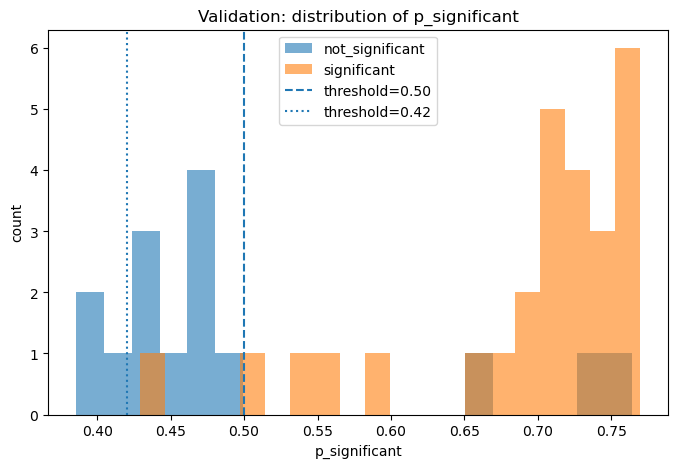

In [190]:
import matplotlib.pyplot as plt

p_val = pd.Series(significance_model.val_proba_, name="p_significant")
y_val = pd.Series(significance_model.y_val_, name="is_significant")

plt.figure(figsize=(8, 5))
plt.hist(p_val[y_val == 0], bins=20, alpha=0.6, label="not_significant")
plt.hist(p_val[y_val == 1], bins=20, alpha=0.6, label="significant")
plt.axvline(0.5, linestyle="--", label="threshold=0.50")
plt.axvline(0.42, linestyle=":", label="threshold=0.42")
plt.title("Validation: distribution of p_significant")
plt.xlabel("p_significant")
plt.ylabel("count")
plt.legend()
plt.show()

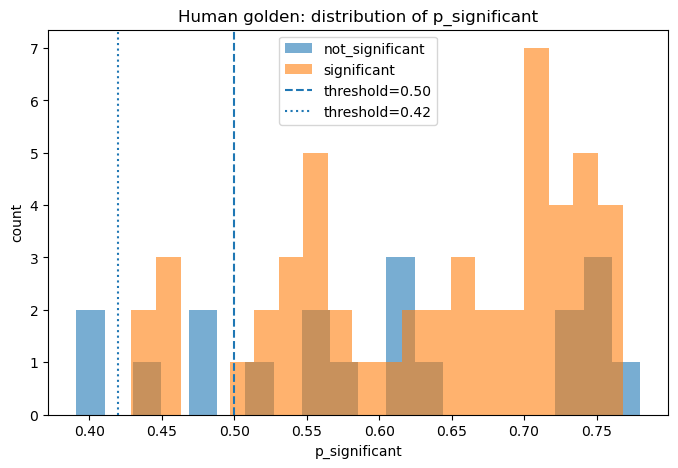

In [191]:
golden_predictions = model_predictions.merge(
    human_df[["news_id", "novelty_label"]],
    on="news_id",
    how="inner",
    suffixes=("_pred", "_human"),
)

golden_predictions["p_significant"] = (
    golden_predictions["comment"]
    .fillna("")
    .str.extract(r"p_significant=([0-9.]+)")[0]
    .astype(float)
)

golden_predictions["is_significant_human"] = (
    golden_predictions["novelty_label_human"].eq("significant").astype(int)
)

golden_prob_rows = golden_predictions.dropna(subset=["p_significant"]).copy()

plt.figure(figsize=(8, 5))
plt.hist(
    golden_prob_rows.loc[golden_prob_rows["is_significant_human"] == 0, "p_significant"],
    bins=20,
    alpha=0.6,
    label="not_significant",
)
plt.hist(
    golden_prob_rows.loc[golden_prob_rows["is_significant_human"] == 1, "p_significant"],
    bins=20,
    alpha=0.6,
    label="significant",
)
plt.axvline(0.5, linestyle="--", label="threshold=0.50")
plt.axvline(0.42, linestyle=":", label="threshold=0.42")
plt.title("Human golden: distribution of p_significant")
plt.xlabel("p_significant")
plt.ylabel("count")
plt.legend()
plt.show()

In [192]:
bins = [0.0, 0.1, 0.2, 0.3, 0.4, 0.42, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

golden_prob_rows["p_bin"] = pd.cut(
    golden_prob_rows["p_significant"],
    bins=bins,
    include_lowest=True,
)

pd.crosstab(
    golden_prob_rows["p_bin"],
    golden_prob_rows["is_significant_human"],
    rownames=["p_significant bin"],
    colnames=["human is_significant"],
)

human is_significant,0,1
p_significant bin,,
"(0.3, 0.4]",1,0
"(0.4, 0.42]",1,0
"(0.42, 0.5]",3,5
"(0.5, 0.6]",4,14
"(0.6, 0.7]",4,12
"(0.7, 0.8]",6,20


In [193]:
golden_prob_rows.sort_values("p_significant")[
    [
        "news_id",
        "title",
        "novelty_label_human",
        "p_significant",
        "comment",
    ]
].head(20)

,news_id,title,novelty_label_human,p_significant,comment
68,89423,На Камчатке за два часа выборов проголосовали ...,minor,0.391,significance_model: p_significant=0.391; thres...
67,89421,"Явка на Сахалине и в Приморье в 2 раза выше, ч...",minor,0.407,significance_model: p_significant=0.407; thres...
82,89497,Московского Манежа больше нет,significant,0.429,significance_model: p_significant=0.429; thres...
62,89493,Аслан Абашидзе заявил о готовности к переговор...,significant,0.436,significance_model: p_significant=0.436; thres...
72,89437,"Вешняков сообщил результаты подсчета 14,7 проц...",,0.449,significance_model: p_significant=0.449; thres...
15,88899,Минск повышает плату за транзит российского га...,significant,0.452,significance_model: p_significant=0.452; thres...
118,90804,"В доме на окраине Мадрида, где прячутся трое т...",significant,0.455,significance_model: p_significant=0.455; thres...
66,89419,На Чукотке и в Корякском АО президентские выбо...,significant,0.459,significance_model: p_significant=0.459; thres...
71,89464,"В Якутии за шесть часов проголосовали 14,65 п...",minor,0.477,significance_model: p_significant=0.477; thres...
76,89443,Выборы президента России состоялись,duplicate,0.480,significance_model: p_significant=0.480; thres...


In [194]:
golden_prob_rows[
    golden_prob_rows["p_significant"].between(0.3, 0.7)
][
    [
        "news_id",
        "title",
        "novelty_label_human",
        "p_significant",
        "comment",
    ]
].sort_values("p_significant")

,news_id,title,novelty_label_human,p_significant,comment
68,89423,На Камчатке за два часа выборов проголосовали ...,minor,0.391,significance_model: p_significant=0.391; thres...
67,89421,"Явка на Сахалине и в Приморье в 2 раза выше, ч...",minor,0.407,significance_model: p_significant=0.407; thres...
82,89497,Московского Манежа больше нет,significant,0.429,significance_model: p_significant=0.429; thres...
62,89493,Аслан Абашидзе заявил о готовности к переговор...,significant,0.436,significance_model: p_significant=0.436; thres...
72,89437,"Вешняков сообщил результаты подсчета 14,7 проц...",,0.449,significance_model: p_significant=0.449; thres...
15,88899,Минск повышает плату за транзит российского га...,significant,0.452,significance_model: p_significant=0.452; thres...
118,90804,"В доме на окраине Мадрида, где прячутся трое т...",significant,0.455,significance_model: p_significant=0.455; thres...
66,89419,На Чукотке и в Корякском АО президентские выбо...,significant,0.459,significance_model: p_significant=0.459; thres...
71,89464,"В Якутии за шесть часов проголосовали 14,65 п...",minor,0.477,significance_model: p_significant=0.477; thres...
76,89443,Выборы президента России состоялись,duplicate,0.480,significance_model: p_significant=0.480; thres...


In [195]:
silver_ids = set(silver_df["news_id"])
golden_ids = set(human_df["news_id"])

overlap_ids = silver_ids & golden_ids

print("silver rows:", len(silver_df))
print("golden rows:", len(human_df))
print("overlap news_id:", len(overlap_ids))

silver rows: 2036
golden rows: 121
overlap news_id: 121


In [196]:
false_negatives = golden_prob_rows[
    (golden_prob_rows["is_significant_human"] == 1)
    & (golden_prob_rows["p_significant"] < 0.5)
].copy()

false_negatives[[
    "news_id",
    "title",
    "novelty_label_human",
    "p_significant",
    "comment",
]].sort_values("p_significant")

,news_id,title,novelty_label_human,p_significant,comment
82,89497,Московского Манежа больше нет,significant,0.429,significance_model: p_significant=0.429; thres...
62,89493,Аслан Абашидзе заявил о готовности к переговор...,significant,0.436,significance_model: p_significant=0.436; thres...
15,88899,Минск повышает плату за транзит российского га...,significant,0.452,significance_model: p_significant=0.452; thres...
118,90804,"В доме на окраине Мадрида, где прячутся трое т...",significant,0.455,significance_model: p_significant=0.455; thres...
66,89419,На Чукотке и в Корякском АО президентские выбо...,significant,0.459,significance_model: p_significant=0.459; thres...


In [198]:
threshold = significance_model.threshold_

false_negatives = golden_prob_rows[
    (golden_prob_rows["is_significant_human"] == 1)
    & (golden_prob_rows["p_significant"] < threshold)
].copy()

false_negatives[[
    "news_id",
    "title",
    "novelty_label_human",
    "p_significant",
    "comment",
]].sort_values("p_significant")

((golden_prob_rows["p_significant"] >= 0.42) & 
 (golden_prob_rows["p_significant"] < 0.50)).sum()

np.int64(8)

In [200]:
changed_by_threshold = golden_prob_rows[
    golden_prob_rows["p_significant"].between(0.42, 0.50, inclusive="left")
].copy()

changed_by_threshold[[
    "news_id",
    "title",
    "novelty_label_human",
    "p_significant",
    "comment",
]].sort_values("p_significant")


,news_id,title,novelty_label_human,p_significant,comment
82,89497,Московского Манежа больше нет,significant,0.429,significance_model: p_significant=0.429; thres...
62,89493,Аслан Абашидзе заявил о готовности к переговор...,significant,0.436,significance_model: p_significant=0.436; thres...
72,89437,"Вешняков сообщил результаты подсчета 14,7 проц...",,0.449,significance_model: p_significant=0.449; thres...
15,88899,Минск повышает плату за транзит российского га...,significant,0.452,significance_model: p_significant=0.452; thres...
118,90804,"В доме на окраине Мадрида, где прячутся трое т...",significant,0.455,significance_model: p_significant=0.455; thres...
66,89419,На Чукотке и в Корякском АО президентские выбо...,significant,0.459,significance_model: p_significant=0.459; thres...
71,89464,"В Якутии за шесть часов проголосовали 14,65 п...",minor,0.477,significance_model: p_significant=0.477; thres...
76,89443,Выборы президента России состоялись,duplicate,0.480,significance_model: p_significant=0.480; thres...


In [201]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def evaluate_golden_threshold(golden_prob_rows, threshold):
    y_true = golden_prob_rows["is_significant_human"].astype(int)
    y_pred = (golden_prob_rows["p_significant"] >= threshold).astype(int)

    return {
        "threshold": threshold,
        "rows": len(golden_prob_rows),
        "predicted_significant": int(y_pred.sum()),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

pd.DataFrame([
    evaluate_golden_threshold(golden_prob_rows, 0.50),
    evaluate_golden_threshold(golden_prob_rows, 0.42),
    evaluate_golden_threshold(golden_prob_rows, 0.40),
    evaluate_golden_threshold(golden_prob_rows, 0.35),
    evaluate_golden_threshold(golden_prob_rows, 0.30),
])

,threshold,rows,predicted_significant,accuracy,precision,recall,f1
0,0.50,70,60,0.728571,0.766667,0.901961,0.828829
1,0.42,70,68,0.757143,0.750000,1.000000,0.857143
2,0.40,70,69,0.742857,0.739130,1.000000,0.850000
3,0.35,70,70,0.728571,0.728571,1.000000,0.842975
4,0.30,70,70,0.728571,0.728571,1.000000,0.842975


In [ ]:
no_proba_golden = golden_predictions[
    golden_predictions["p_significant"].isna()
].copy()

no_proba_golden[[
    "news_id",
    "title",
    "novelty_label_human",
    "comment",
]]

no_proba_golden["novelty_label_human"].value_counts(dropna=False)

novelty_label_human
                 25
significant      22
wrong_cluster     2
minor             2
Name: count, dtype: int64

In [ ]:
first_item_errors = no_proba_golden[
    no_proba_golden["novelty_label_human"].eq("significant")
].copy()
first_item_errors.head()

,news_id,published_at,topic,title,text,cluster_id,novelty_label_pred,comment,needs_review,novelty_label_human,p_significant,is_significant_human
6,88596,2004-03-01,Мир,Изгнанный президент Гаити прилетел в Центральн...,"Президент Гаити Жан-Бертран Аристид, бежавший ...",baseline_cluster_00038,,significance_model: first item in cluster,False,significant,NaN,1
16,88687,2004-03-02,Экономика,"Кредитный рейтинг ""ЮКОСа"" сделают еще негативнее",Международное рейтинговое агентство Standard &...,baseline_cluster_00100,,significance_model: first item in cluster,False,significant,NaN,1
17,88715,2004-03-03,Россия,Уничтожившие Гелаева пограничники представлены...,К правительственным наградам представлены погр...,baseline_cluster_00119,,significance_model: first item in cluster,False,significant,NaN,1
21,88728,2004-03-03,Экономика,"""Транс Нафта"" продлила поставки газа в Белоруссию","Российская компания ""Транс Нафта"" и белорусски...",baseline_cluster_00129,,significance_model: first item in cluster,False,significant,NaN,1
35,88827,2004-03-04,Мир,На родине культа вуду введено чрезвычайное пол...,В карибском островном государстве Гаити введен...,baseline_cluster_00194,,significance_model: first item in cluster,False,significant,NaN,1
